# Whale Entrance Animation Weights Analysis — KNS-224

**Problem**: During the 5s entrance, `surface=1` and all directional weights (`fwd`, `up`, `down`, `left`, `right`) = 0.
The whale glides in without wagging its tail because the blend loop **forces** `dirs=0` whenever `enteringScene` is true.

**Root cause** (from `hero-egg-3d.component.ts`):

```typescript
// Line 1066-1073 — per-frame blend loop
for (const [dir, action] of Object.entries(this.dirActions)) {
    // targetWeight is ALWAYS 0 during entrance because !this.enteringScene === false
    const targetWeight = (!this.enteringScene && dir === this.activeDir && !this.isReacting) ? 1 : 0;
    ...
}

// Line 1076-1083 — surface is forced to 1
const surfaceTarget = this.enteringScene ? 1 : 0;
```

`switchDirection()` correctly updates `this.activeDir`, but the blend loop ignores it during entrance.

*Generated by Claude*

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# --- Match TypeScript constants ---
BLEND_SPEED = 0.6
ENTRANCE_DURATION = 5.0  # seconds
FPS = 60
WAVE_AMPLITUDE = 0.6
WAVE_CYCLES = 2.5

# Scene parameters
DESIRED_HALF_HEIGHT = 1.0
CAMERA_FOV = 45
ASPECT_RATIO = 16 / 9
vFov = CAMERA_FOV * np.pi / 180
camZ = DESIRED_HALF_HEIGHT / np.tan(vFov / 2)
swimRangeY = DESIRED_HALF_HEIGHT
swimRangeX = DESIRED_HALF_HEIGHT * ASPECT_RATIO
swimRangeZ = camZ * 0.3

# Simulate frame-by-frame
total_frames = int(ENTRANCE_DURATION * FPS)
delta = 1.0 / FPS

# Replicate computeDesiredDirection
def compute_desired_direction(vx, vy, current_dir):
    ax, ay = abs(vx), abs(vy)
    if ax < 0.1 and ay < 0.1:
        return current_dir
    if ax > ay:
        return 'right' if vx > 0 else 'left'
    else:
        return 'up' if vy > 0 else 'down'

print(f"Simulating {total_frames} frames at {FPS}fps over {ENTRANCE_DURATION}s")
print(f"BLEND_SPEED={BLEND_SPEED}, delta={delta:.4f}, blendStep={BLEND_SPEED*delta:.4f}, lerpFactor={min(BLEND_SPEED*delta*4, 1):.4f}")

Simulating 300 frames at 60fps over 5.0s
BLEND_SPEED=0.6, delta=0.0167, blendStep=0.0100, lerpFactor=0.0400


## 1. Current behavior — the bug

Simulates the per-frame blend loop exactly as TypeScript has it.
During entrance: `targetWeight = (!enteringScene && dir === activeDir) ? 1 : 0` — since `enteringScene=true`, ALL dir targets are 0.

In [2]:
def simulate_entrance(fix_applied=False):
    """Simulate frame-by-frame weight blending during entrance.
    
    fix_applied=False: current buggy behavior (dirs always 0 during entrance)
    fix_applied=True:  proposed fix (dirs blend to activeDir during entrance too)
    """
    dirs = ['right', 'left', 'up', 'down', 'fwd']
    
    # State
    entering_scene = True
    active_dir = 'right'  # initial direction
    pending_dir = 'right'
    pending_dir_since = 0
    ENTRANCE_HOLD_TIME = 500  # ms
    
    # Weights (match init: surface=1, all dirs=0)
    weights = {d: 0.0 for d in dirs}
    surface_weight = 1.0
    
    # History for plotting
    history = {d: [] for d in dirs}
    history['surface'] = []
    history['time'] = []
    history['active_dir'] = []
    history['pos_y'] = []
    history['entrance_vx'] = []
    history['entrance_vy'] = []
    history['timescale'] = []
    
    for frame in range(total_frames):
        t = frame / total_frames  # 0..1
        time_s = t * ENTRANCE_DURATION
        time_ms = time_s * 1000
        
        # --- Blend loop (runs every frame, BEFORE position update) ---
        blend_step = BLEND_SPEED * delta
        lerp_factor = min(blend_step * 4, 1)
        
        for d in dirs:
            if fix_applied:
                # PROPOSED FIX: allow activeDir weight during entrance
                target_w = 1.0 if (d == active_dir) else 0.0
            else:
                # CURRENT BUG: dirs always 0 during entrance
                target_w = 1.0 if (not entering_scene and d == active_dir) else 0.0
            weights[d] += (target_w - weights[d]) * lerp_factor
        
        if fix_applied:
            # PROPOSED FIX: surface blends down as dir blends up
            surface_target = 0.0  # let dirs take over immediately
        else:
            # CURRENT: surface=1 during entire entrance
            surface_target = 1.0 if entering_scene else 0.0
        surface_weight += (surface_target - surface_weight) * lerp_factor
        
        # --- Position & velocity (entrance logic) ---
        ease_out = 1 - (1 - t)**3
        one_minus_t = 1 - t
        
        # Y position
        envelope = np.sin(np.pi * t)
        pos_y = WAVE_AMPLITUDE * swimRangeY * np.sin(t * WAVE_CYCLES * 2 * np.pi) * envelope
        
        # Velocity
        entrance_vx = 3 * one_minus_t**2
        wY = WAVE_CYCLES * 2 * np.pi
        entrance_vy = WAVE_AMPLITUDE * swimRangeY * (
            wY * np.cos(wY * t) * envelope + np.pi * np.sin(wY * t) * np.cos(np.pi * t)
        )
        
        # timeScale
        speed_factor = one_minus_t**2
        entrance_timescale = 0.3 + 0.9 * speed_factor
        
        # Direction switching (only when moving fast enough)
        if entrance_timescale > 0.4:
            desired = compute_desired_direction(entrance_vx, entrance_vy, active_dir)
            if desired != pending_dir:
                pending_dir = desired
                pending_dir_since = time_ms
            if pending_dir != active_dir and (time_ms - pending_dir_since) >= ENTRANCE_HOLD_TIME:
                active_dir = pending_dir
        
        # Record
        history['time'].append(time_s)
        for d in dirs:
            history[d].append(weights[d])
        history['surface'].append(surface_weight)
        history['active_dir'].append(active_dir)
        history['pos_y'].append(pos_y)
        history['entrance_vx'].append(entrance_vx)
        history['entrance_vy'].append(entrance_vy)
        history['timescale'].append(entrance_timescale)
    
    return history

# Run current (buggy) simulation
current = simulate_entrance(fix_applied=False)
print("Simulation complete (current/buggy behavior)")
print(f"  Surface weight: always {current['surface'][0]:.2f} -> {current['surface'][-1]:.2f}")
print(f"  Dir weights at end: { {d: f'{current[d][-1]:.4f}' for d in ['right','left','up','down','fwd']} }")
print(f"  Active dir changes: {sum(1 for i in range(1,len(current['active_dir'])) if current['active_dir'][i] != current['active_dir'][i-1])}")

Simulation complete (current/buggy behavior)
  Surface weight: always 1.00 -> 1.00
  Dir weights at end: {'right': '0.0000', 'left': '0.0000', 'up': '0.0000', 'down': '0.0000', 'fwd': '0.0000'}
  Active dir changes: 3


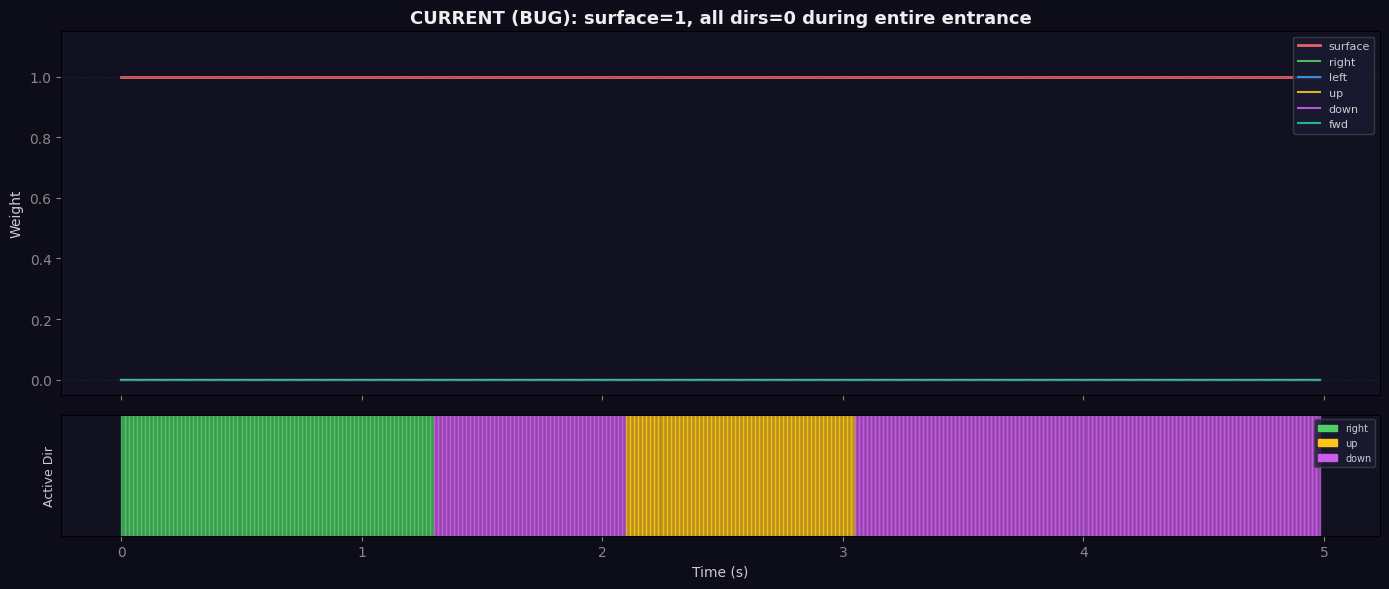


The whale plays ONLY the surface (idle bob) animation.
All directional animations (which drive the tail) have weight=0.


In [3]:
def plot_weights(history, title, ax_weights, ax_dir):
    """Plot animation weights and active direction over time."""
    t = history['time']
    
    colors = {
        'surface': '#ff6b6b',
        'right': '#51cf66', 'left': '#339af0',
        'up': '#fcc419', 'down': '#cc5de8', 'fwd': '#20c997'
    }
    
    for key in ['surface', 'right', 'left', 'up', 'down', 'fwd']:
        ax_weights.plot(t, history[key], color=colors[key], linewidth=2 if key == 'surface' else 1.5,
                       label=key, alpha=0.9)
    
    ax_weights.set_ylabel('Weight', color='#ccc')
    ax_weights.set_ylim(-0.05, 1.15)
    ax_weights.set_title(title, color='#eee', fontsize=13, fontweight='bold')
    ax_weights.legend(loc='upper right', fontsize=8, facecolor='#1a1a33', edgecolor='#444', labelcolor='#ccc')
    ax_weights.axhline(1, color='#333', ls=':', lw=0.5)
    ax_weights.axhline(0, color='#333', ls=':', lw=0.5)
    ax_weights.set_facecolor('#111122')
    ax_weights.tick_params(colors='#888')
    
    # Direction timeline
    dir_colors = {'right': '#51cf66', 'left': '#339af0', 'up': '#fcc419', 'down': '#cc5de8', 'fwd': '#20c997'}
    for i in range(len(t)-1):
        ax_dir.axvspan(t[i], t[i+1], color=dir_colors.get(history['active_dir'][i], '#666'), alpha=0.7)
    ax_dir.set_ylabel('Active Dir', color='#ccc', fontsize=9)
    ax_dir.set_xlabel('Time (s)', color='#ccc')
    ax_dir.set_facecolor('#111122')
    ax_dir.tick_params(colors='#888')
    ax_dir.set_yticks([])
    patches = [mpatches.Patch(color=c, label=d) for d, c in dir_colors.items() 
               if d in set(history['active_dir'])]
    ax_dir.legend(handles=patches, loc='upper right', fontsize=7, facecolor='#1a1a33',
                 edgecolor='#444', labelcolor='#ccc')

# Plot current (buggy)
fig, axes = plt.subplots(2, 1, figsize=(14, 6), facecolor='#0d0d1a',
                          gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
plot_weights(current, 'CURRENT (BUG): surface=1, all dirs=0 during entire entrance', axes[0], axes[1])
plt.tight_layout()
plt.show()

print("\nThe whale plays ONLY the surface (idle bob) animation.")
print("All directional animations (which drive the tail) have weight=0.")

## 2. Proposed fix — let directional animations play during entrance

**The fix**: Remove the `!this.enteringScene` guard from the dir weight target.
During entrance, `activeDir` should drive the tail animation just like in free-swim.
Surface weight drops to 0 so the directional animation fully takes over.

```typescript
// BEFORE (line 1069):
const targetWeight = (!this.enteringScene && dir === this.activeDir && !this.isReacting) ? 1 : 0;

// AFTER:
const targetWeight = (dir === this.activeDir && !this.isReacting) ? 1 : 0;

// BEFORE (line 1078):
const surfaceTarget = this.enteringScene ? 1 : 0;

// AFTER:
const surfaceTarget = 0;  // surface is never needed — dirs handle everything
```

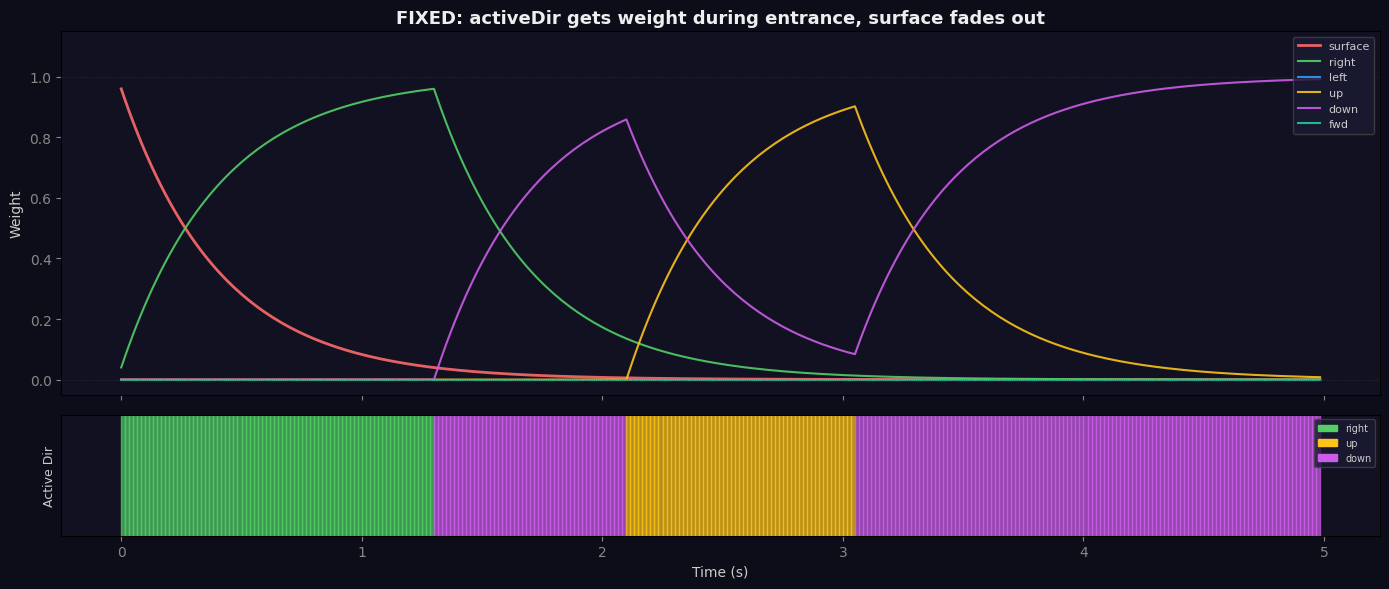

  Surface weight: 0.96 -> 0.0000 (fades to ~0)
  Dir weights at end: {'right': '0.0001', 'left': '0.0000', 'up': '0.0079', 'down': '0.9920', 'fwd': '0.0000'}
  Active dir changes: 3


In [4]:
# Run proposed fix simulation
fixed = simulate_entrance(fix_applied=True)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), facecolor='#0d0d1a',
                          gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
plot_weights(fixed, 'FIXED: activeDir gets weight during entrance, surface fades out', axes[0], axes[1])
plt.tight_layout()
plt.show()

print(f"  Surface weight: {fixed['surface'][0]:.2f} -> {fixed['surface'][-1]:.4f} (fades to ~0)")
print(f"  Dir weights at end: { {d: f'{fixed[d][-1]:.4f}' for d in ['right','left','up','down','fwd']} }")
print(f"  Active dir changes: {sum(1 for i in range(1,len(fixed['active_dir'])) if fixed['active_dir'][i] != fixed['active_dir'][i-1])}")

## 3. Side-by-side comparison

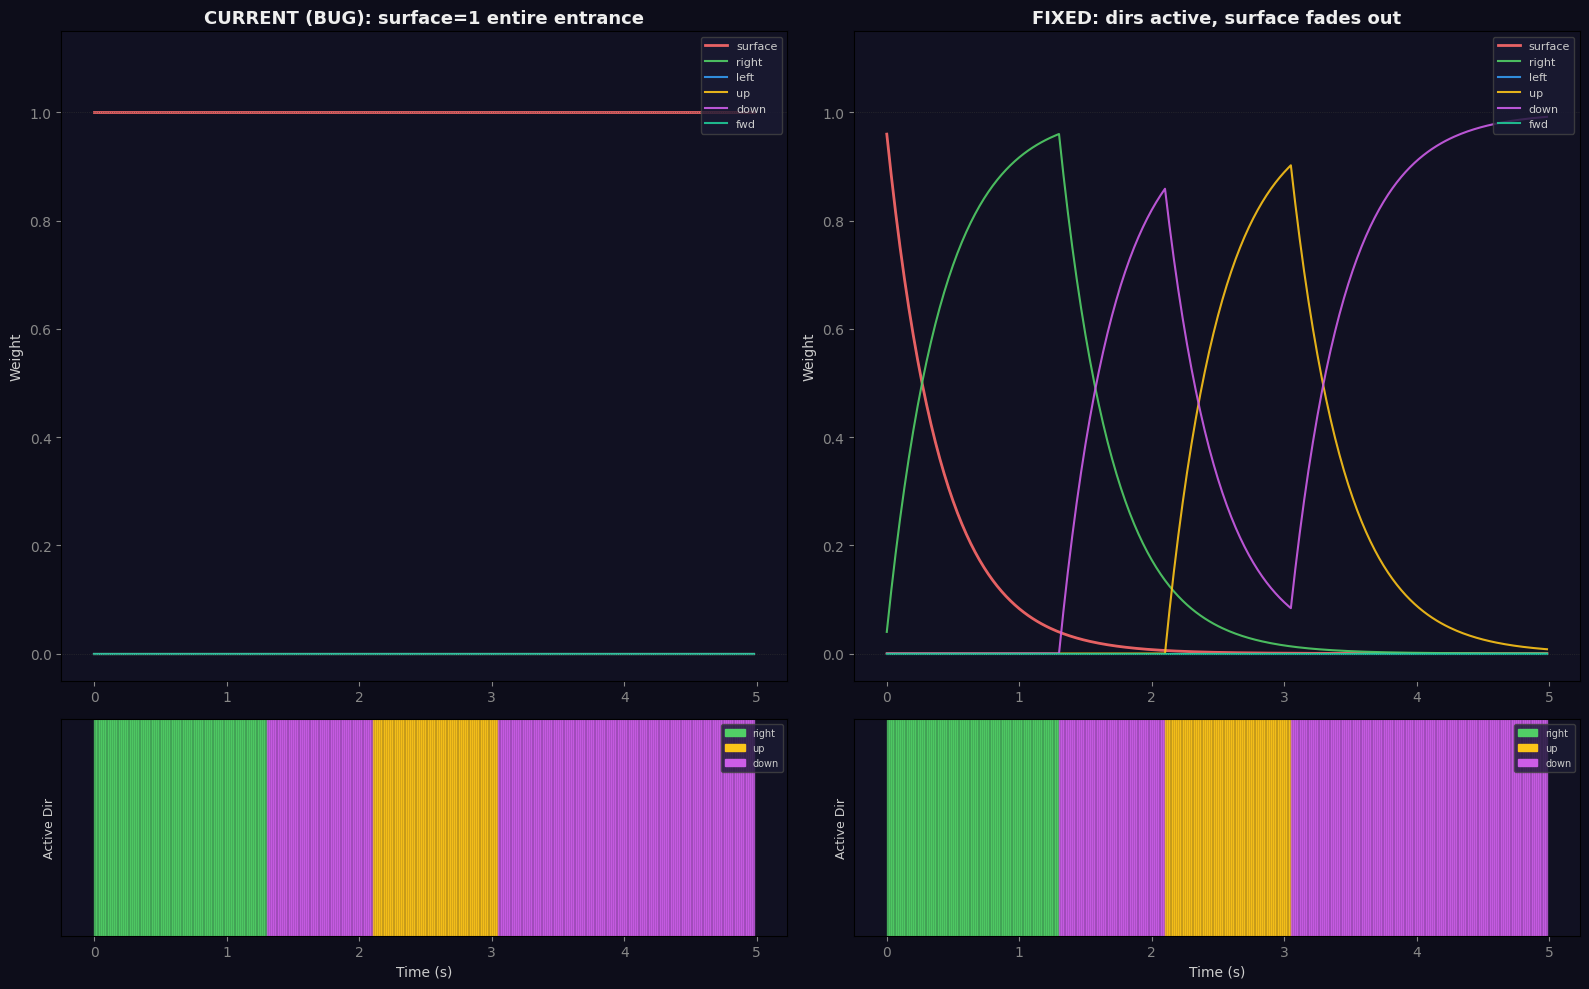

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), facecolor='#0d0d1a',
                          gridspec_kw={'height_ratios': [3, 1]})

plot_weights(current, 'CURRENT (BUG): surface=1 entire entrance', axes[0, 0], axes[1, 0])
plot_weights(fixed, 'FIXED: dirs active, surface fades out', axes[0, 1], axes[1, 1])

plt.tight_layout()
plt.show()

## 4. Velocity vs direction picking — does the whale change direction enough?

The entrance velocity drives `computeDesiredDirection()`. Let's see what directions get picked and when.

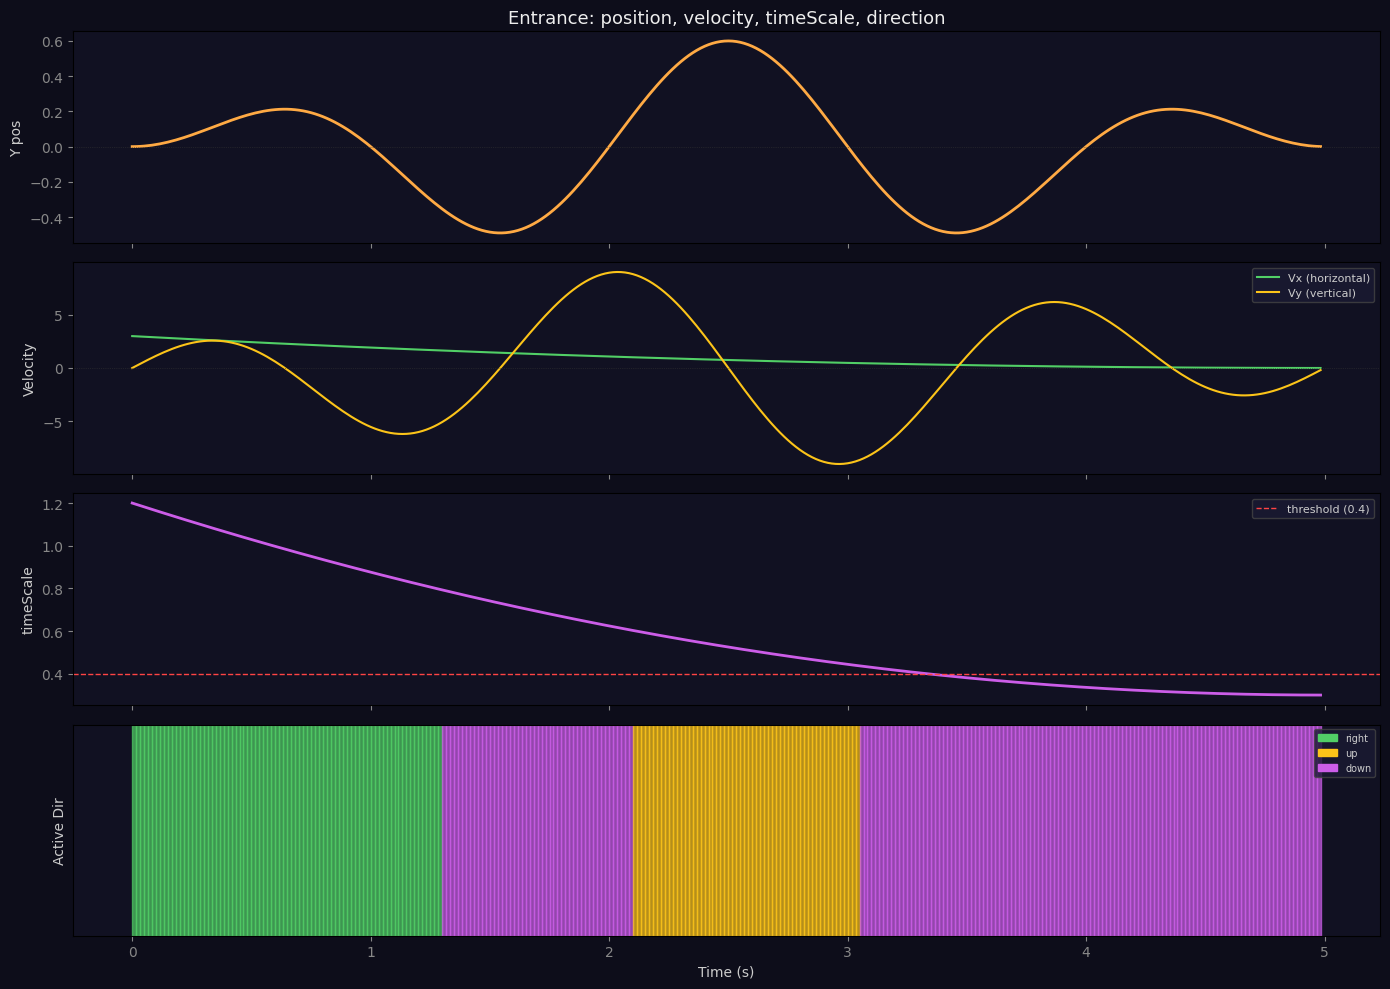


Direction changes (3 total):
  t=1.30s -> down
  t=2.10s -> up
  t=3.05s -> down


In [6]:
fig, axes = plt.subplots(4, 1, figsize=(14, 10), facecolor='#0d0d1a', sharex=True)
t = fixed['time']

# Y position
axes[0].set_facecolor('#111122')
axes[0].plot(t, fixed['pos_y'], '#ffaa44', linewidth=2)
axes[0].set_ylabel('Y pos', color='#ccc')
axes[0].set_title('Entrance: position, velocity, timeScale, direction', color='#eee', fontsize=13)
axes[0].axhline(0, color='#333', ls=':', lw=0.5)
axes[0].tick_params(colors='#888')

# Velocity components
axes[1].set_facecolor('#111122')
axes[1].plot(t, fixed['entrance_vx'], '#51cf66', linewidth=1.5, label='Vx (horizontal)')
axes[1].plot(t, fixed['entrance_vy'], '#fcc419', linewidth=1.5, label='Vy (vertical)')
axes[1].axhline(0, color='#333', ls=':', lw=0.5)
axes[1].set_ylabel('Velocity', color='#ccc')
axes[1].legend(fontsize=8, facecolor='#1a1a33', edgecolor='#444', labelcolor='#ccc')
axes[1].tick_params(colors='#888')

# timeScale
axes[2].set_facecolor('#111122')
axes[2].plot(t, fixed['timescale'], '#cc5de8', linewidth=2)
axes[2].axhline(0.4, color='#ff4444', ls='--', lw=1, label='threshold (0.4)')
axes[2].set_ylabel('timeScale', color='#ccc')
axes[2].legend(fontsize=8, facecolor='#1a1a33', edgecolor='#444', labelcolor='#ccc')
axes[2].tick_params(colors='#888')

# Direction timeline
dir_colors = {'right': '#51cf66', 'left': '#339af0', 'up': '#fcc419', 'down': '#cc5de8', 'fwd': '#20c997'}
for i in range(len(t)-1):
    axes[3].axvspan(t[i], t[i+1], color=dir_colors.get(fixed['active_dir'][i], '#666'), alpha=0.7)
axes[3].set_ylabel('Active Dir', color='#ccc')
axes[3].set_xlabel('Time (s)', color='#ccc')
axes[3].set_facecolor('#111122')
axes[3].tick_params(colors='#888')
axes[3].set_yticks([])
patches = [mpatches.Patch(color=c, label=d) for d, c in dir_colors.items() if d in set(fixed['active_dir'])]
axes[3].legend(handles=patches, fontsize=7, facecolor='#1a1a33', edgecolor='#444', labelcolor='#ccc')

plt.tight_layout()
plt.show()

# Summary stats
dirs_seq = fixed['active_dir']
changes = [(t[i], dirs_seq[i]) for i in range(1, len(dirs_seq)) if dirs_seq[i] != dirs_seq[i-1]]
print(f"\nDirection changes ({len(changes)} total):")
for time_s, d in changes:
    print(f"  t={time_s:.2f}s -> {d}")

## 5. Exact TypeScript diff

Two lines to change in `hero-egg-3d.component.ts`:

In [7]:
print("""
=== DIFF for web/src/app/marketplace/hero-egg-3d.component.ts ===

--- Line ~1069 (dir weight target) ---
BEFORE:
  const targetWeight = (!this.enteringScene && dir === this.activeDir && !this.isReacting) ? 1 : 0;
AFTER:
  const targetWeight = (dir === this.activeDir && !this.isReacting) ? 1 : 0;

--- Line ~1078 (surface weight target) ---
BEFORE:
  const surfaceTarget = this.enteringScene ? 1 : 0;
AFTER:
  const surfaceTarget = 0;

--- Line ~1035 (surface init weight — optional cleanup) ---
BEFORE:
  this.surfaceAction.setEffectiveWeight(1); // starts active (entrance)
AFTER:
  this.surfaceAction.setEffectiveWeight(0); // dirs handle animation from the start

--- Line ~1061 (comment fix) ---
BEFORE:
  // During entrance: surface=1, all dir=0
AFTER:
  // activeDir=1 always (entrance + free-swim), surface=0

WHY:
- switchDirection() already correctly updates activeDir during entrance
- The blend loop was overriding it by forcing dirs=0 when enteringScene=true
- Surface animation is a static idle bob with no tail movement
- Directional animations (right, up, down, etc.) drive the tail wag
- With the fix, the whale actively swims (wags tail) from frame 1 of entrance
""")


=== DIFF for web/src/app/marketplace/hero-egg-3d.component.ts ===

--- Line ~1069 (dir weight target) ---
BEFORE:
  const targetWeight = (!this.enteringScene && dir === this.activeDir && !this.isReacting) ? 1 : 0;
AFTER:
  const targetWeight = (dir === this.activeDir && !this.isReacting) ? 1 : 0;

--- Line ~1078 (surface weight target) ---
BEFORE:
  const surfaceTarget = this.enteringScene ? 1 : 0;
AFTER:
  const surfaceTarget = 0;

--- Line ~1035 (surface init weight — optional cleanup) ---
BEFORE:
  this.surfaceAction.setEffectiveWeight(1); // starts active (entrance)
AFTER:
  this.surfaceAction.setEffectiveWeight(0); // dirs handle animation from the start

--- Line ~1061 (comment fix) ---
BEFORE:
  // During entrance: surface=1, all dir=0
AFTER:
  // activeDir=1 always (entrance + free-swim), surface=0

WHY:
- switchDirection() already correctly updates activeDir during entrance
- The blend loop was overriding it by forcing dirs=0 when enteringScene=true
- Surface animation is a s